# 27 — Understand desk and portfolio exposures

Compare meaningful pre-aggregation risk indicators across desks and sub-portfolios.

SBM capital is not fully additive by desk because netting and correlation are portfolio-level. Actual INR bump effects show where exposure originates without presenting a false capital allocation.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

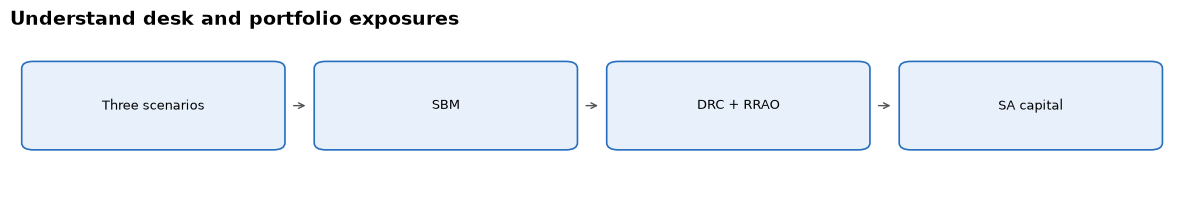

In [2]:
draw_flow(['Three scenarios', 'SBM', 'DRC + RRAO', 'SA capital'],'Understand desk and portfolio exposures',wrap_after=4)

For each delta and vega row, calculate shocked value minus base value, then show gross and signed effects by desk.

$$\text{bump effect}=V_{shocked}-V_{base}$$

In [3]:
delta=pd.read_csv(RUN/'03_delta_trade_level.csv'); vega=pd.read_csv(RUN/'04_vega_trade_level.csv')
effects=pd.concat([delta.assign(measure='Delta'),vega.assign(measure='Vega')],ignore_index=True)
effects['bump_effect_inr']=effects.shocked_value_inr-effects.base_value_inr
desk=effects.groupby(['desk','measure']).agg(signed_effect=('bump_effect_inr','sum'),gross_effect=('bump_effect_inr',lambda x:x.abs().sum())).reset_index()
display(crore_table(desk,['signed_effect','gross_effect']))
portfolio=effects.groupby(['desk','sub_portfolio','risk_class'])['bump_effect_inr'].apply(lambda x:x.abs().sum()).reset_index()
display_sample(crore_table(portfolio,['bump_effect_inr']),30)

,desk,measure,Signed Effect (INR crore),Gross Effect (INR crore)
0,Commodity,Delta,1.0761,2.8653
1,Commodity,Vega,0.0365,0.1580
2,Credit,Delta,0.3300,0.7093
3,Credit,Vega,-0.0483,0.0528
4,Equity,Delta,1.0027,1.7656
5,Equity,Vega,-0.0719,0.1539
6,FX,Delta,0.1136,0.5515
7,FX,Vega,0.0757,0.0757
8,Rates,Delta,0.3384,0.4491
9,Rates,Vega,0.0631,0.0631


Displayed rows: first 30 of 57 observations, in table order.


,desk,sub_portfolio,risk_class,Bump Effect (INR crore)
0,Commodity,Energy,COMMODITY,1.7861
1,Commodity,Energy,FX,0.0215
2,Commodity,Options,COMMODITY,0.4418
3,Commodity,Options,FX,0.0482
4,Commodity,Options,GIRR,0.0016
5,Commodity,Precious Metals,COMMODITY,0.7180
6,Commodity,Precious Metals,FX,0.0060
7,Credit,Callable,CSR_NON_SECURITISATION,0.0526
8,Credit,Callable,FX,0.0813
9,Credit,Callable,GIRR,0.0030


The visual below uses the calculated rows shown above.

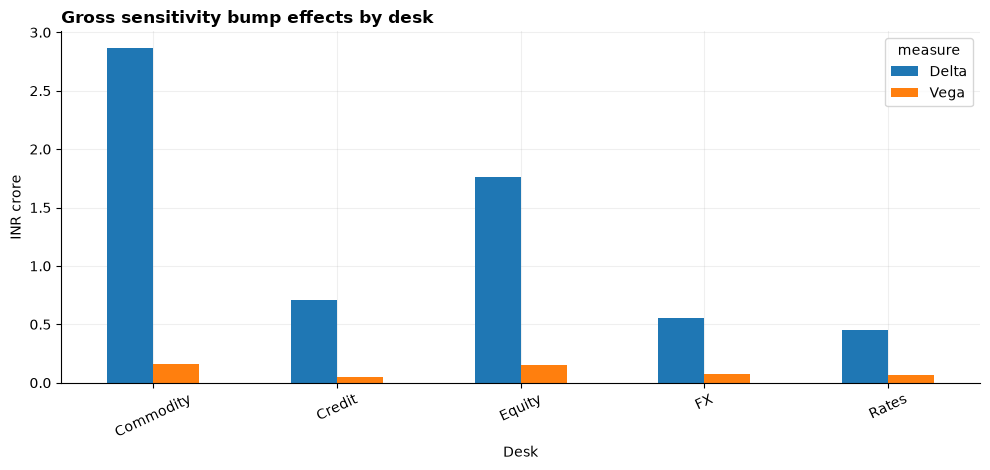

In [4]:
plot=desk.pivot(index='desk',columns='measure',values='gross_effect').fillna(0)/INR_CRORE
plot.plot(kind='bar'); plt.title('Gross sensitivity bump effects by desk',loc='left',weight='bold')
plt.ylabel('INR crore'); plt.xlabel('Desk'); plt.xticks(rotation=25)
plt.tight_layout(); plt.show()

This explains the source of risk while preserving portfolio-level regulatory aggregation.